# Ventas mensuales de pastelería

# Concepto
## Este análisis busca comparar los ingresos por ventas y la rentabilidad real (ventas – gastos diarios) en cada día de la semana.
## La idea es mostrar que vender mucho no siempre significa ganar mucho, ya que los gastos pueden variar.


In [22]:
#Carga de las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [23]:
#Carga y vizualización de los datasets
#Dataset de ventas
ventas = pd.read_csv("Ventas_Pasteleria.csv", encoding="latin1")  # Para cambiar caracteres especiales
ventas.info()

#Dataset de gastos
gastos = pd.read_csv("Gastos_Pasteleria.csv", encoding="latin1")  # Para cambiar caracteres especiales
gastos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mes                 66 non-null     object 
 1   Semana              66 non-null     int64  
 2   Dia de la semana    66 non-null     object 
 3   Fecha               66 non-null     object 
 4   Venta Tarjeta       63 non-null     float64
 5   Venta Efectivo      63 non-null     float64
 6   Venta Caldos Leo    63 non-null     float64
 7   Venta Caldos Riesi  63 non-null     float64
 8   Total por dia       63 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mes       145 non-null    object 
 1   semana    144 non-null    object 
 2   concepto  144 non-null    object

In [24]:
#Limpieza en el dataset Ventas
ventas["Fecha"] = pd.to_datetime(ventas["Fecha"], dayfirst=True, errors="coerce")
cols_num = ["Venta Tarjeta","Venta Efectivo","Venta Caldos Leo","Venta Caldos Riesi","Total por dia"]
ventas[cols_num] = ventas[cols_num].apply(pd.to_numeric, errors="coerce")
ventas["Semana"] = ventas["Semana"].astype(int)

In [25]:
# === Limpieza de Gastos ===
gastos = pd.read_csv("Gastos_Pasteleria.csv", encoding="latin1")
# Normalizar nombres de columnas
gastos.columns = gastos.columns.str.strip().str.lower()
# Reemplazar caracteres raros en la columna 'semana'
# Usamos regex para reemplazar cualquier carácter no numérico por un guion
gastos["semana"] = gastos["semana"].astype(str).str.replace(r"[^\d]", "-", regex=True).str.strip()
# Crear mapa de rangos a número de semana
mapa_semanas = {
    "01-07": 1,
    "08-14": 2,
    "15-21": 3,
    "22-28": 4,
    "29-31": 5
}
# Asignar semana_num usando el mapa
gastos["semana_num"] = gastos["semana"].map(mapa_semanas)
# Validar resultado
print(gastos[["mes","semana","semana_num","concepto","monto"]].head(40))

          mes semana  semana_num                       concepto    monto
0   Diciembre  01-07         1.0                         Nomina  9415.84
1   Diciembre  08-14         2.0                         Nomina  9415.84
2   Diciembre  15-21         3.0                         Nomina  9415.84
3   Diciembre  22-28         4.0                         Nomina  9415.84
4   Diciembre  29-31         5.0                         Nomina  9415.84
5   Diciembre  15-21         3.0                    Nomina Alex  6000.00
6   Diciembre  29-31         5.0                    Nomina Alex  6000.00
7   Diciembre  01-07         1.0                            Gas   600.00
8   Diciembre  08-14         2.0                            Gas   600.00
9   Diciembre  15-21         3.0                            Gas   600.00
10  Diciembre  22-28         4.0                            Gas   600.00
11  Diciembre  29-31         5.0                            Gas   600.00
12  Diciembre  01-07         1.0         Repartidor

In [26]:
# Normalizar columna Mes en ventas
ventas["Mes"] = ventas["Mes"].str.strip().str.lower()
# Normalizar columna mes en gastos
gastos["mes"] = gastos["mes"].str.strip().str.lower()
# Agrupar gastos por mes y semana_num
gastos_semana = gastos.groupby(["mes","semana_num"], as_index=False)["monto"].sum()
# Convertir semana en ventas a int
ventas["Semana"] = ventas["Semana"].astype(int)
# Merge corregido
ventas_gastos = ventas.merge(
    gastos_semana,
    left_on=["Mes","Semana"],
    right_on=["mes","semana_num"],
    how="left"
)
print(ventas_gastos[["Mes","Semana","Fecha","Total por dia","monto"]].head(30))

          Mes  Semana      Fecha  Total por dia     monto
0   diciembre       1 2025-12-01         3370.0  17388.48
1   diciembre       1 2025-12-02         1560.0  17388.48
2   diciembre       1 2025-12-03         3265.0  17388.48
3   diciembre       1 2025-12-04         2670.0  17388.48
4   diciembre       1 2025-12-05         4755.0  17388.48
5   diciembre       1 2025-12-06         4265.0  17388.48
6   diciembre       1 2025-12-07         4270.0  17388.48
7   diciembre       2 2025-12-08         4220.0  27566.34
8   diciembre       2 2025-12-09         3490.0  27566.34
9   diciembre       2 2025-12-10         3080.0  27566.34
10  diciembre       2 2025-12-11         1875.0  27566.34
11  diciembre       2 2025-12-12         5440.0  27566.34
12  diciembre       2 2025-12-13         2050.0  27566.34
13  diciembre       2 2025-12-14         7038.0  27566.34
14  diciembre       3 2025-12-15         5238.0  21646.84
15  diciembre       3 2025-12-16         1440.0  21646.84
16  diciembre 

## Rentabilidad

In [27]:
#Calcular percentiles de rentabilidad.
# Primero, verifica si las columnas requeridas existen en el DataFrame
# Si los nombres de las columnas son diferentes, reemplázalos con los nombres reales de tu DataFrame
if 'ventas' not in ventas_gastos.columns:
    print("Column 'ventas' not found. Please check your column names.")
    # Podrías querer listar las columnas disponibles para ayudar a identificar las correctas
    print("Available columns:", ventas_gastos.columns.tolist())
elif 'gastos' not in ventas_gastos.columns:
    print("Column 'gastos' not found. Please check your column names.")
    print("Available columns:", ventas_gastos.columns.tolist())
else:
    # Si ambas columnas existen, procede con el cálculo
    if "rentabilidad_diaria" not in ventas_gastos.columns:
        ventas_gastos["rentabilidad_diaria"] = ventas_gastos["ventas"] - ventas_gastos["gastos"]

    q25 = ventas_gastos["rentabilidad_diaria"].quantile(0.25)
    q75 = ventas_gastos["rentabilidad_diaria"].quantile(0.75)

Column 'ventas' not found. Please check your column names.
Available columns: ['Mes', 'Semana', 'Dia de la semana', 'Fecha', 'Venta Tarjeta', 'Venta Efectivo', 'Venta Caldos Leo', 'Venta Caldos Riesi', 'Total por dia', 'mes', 'semana_num', 'monto']


In [28]:
#Función de clasificación
def clasificar_dia(x):
    if pd.isna(x):
        return "sin datos"
    elif x < q25:
        return "flojo"
    elif x > q75:
        return "bueno"
    else:
        return "normal"

# Primero, crear la columna rentabilidad_diaria si no existe
# Asumiendo que podría calcularse a partir de 'Total por dia' u otras columnas
ventas_gastos["rentabilidad_diaria"] = ventas_gastos["Total por dia"]  # O el cálculo que corresponda

# Calcular los percentiles 25 y 75 de la rentabilidad diaria
# Estos valores se usarán para clasificar los días
q25 = ventas_gastos["rentabilidad_diaria"].quantile(0.25)
q75 = ventas_gastos["rentabilidad_diaria"].quantile(0.75)

# Crear columna de categoría
ventas_gastos["categoria_dia"] = ventas_gastos["rentabilidad_diaria"].apply(clasificar_dia)

# Validar resultado
print(ventas_gastos[["Mes","Semana","Fecha","Total por dia","rentabilidad_diaria","categoria_dia"]].head(30))

          Mes  Semana      Fecha  Total por dia  rentabilidad_diaria  \
0   diciembre       1 2025-12-01         3370.0               3370.0   
1   diciembre       1 2025-12-02         1560.0               1560.0   
2   diciembre       1 2025-12-03         3265.0               3265.0   
3   diciembre       1 2025-12-04         2670.0               2670.0   
4   diciembre       1 2025-12-05         4755.0               4755.0   
5   diciembre       1 2025-12-06         4265.0               4265.0   
6   diciembre       1 2025-12-07         4270.0               4270.0   
7   diciembre       2 2025-12-08         4220.0               4220.0   
8   diciembre       2 2025-12-09         3490.0               3490.0   
9   diciembre       2 2025-12-10         3080.0               3080.0   
10  diciembre       2 2025-12-11         1875.0               1875.0   
11  diciembre       2 2025-12-12         5440.0               5440.0   
12  diciembre       2 2025-12-13         2050.0               20

## Visualizacion de rentabilidad.

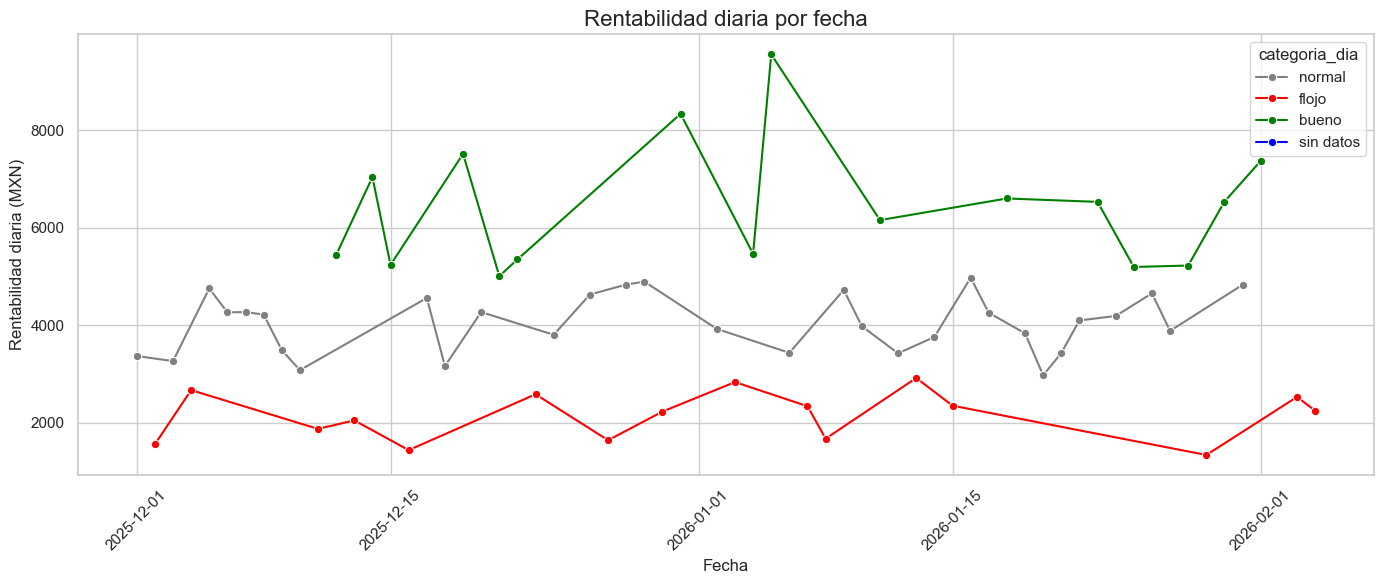

In [29]:
# Configuración de estilo
sns.set(style="whitegrid")

# Gráfico de línea con puntos por día
plt.figure(figsize=(14,6))
sns.lineplot(data=ventas_gastos, x="Fecha", y="rentabilidad_diaria", marker="o", hue="categoria_dia", 
             palette={"flojo":"red","normal":"gray","bueno":"green","sin datos":"blue"})  # Added "sin datos" category

# Títulos y etiquetas
plt.title("Rentabilidad diaria por fecha", fontsize=16)
plt.xlabel("Fecha")
plt.ylabel("Rentabilidad diaria (MXN)")
plt.xticks(rotation=45)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

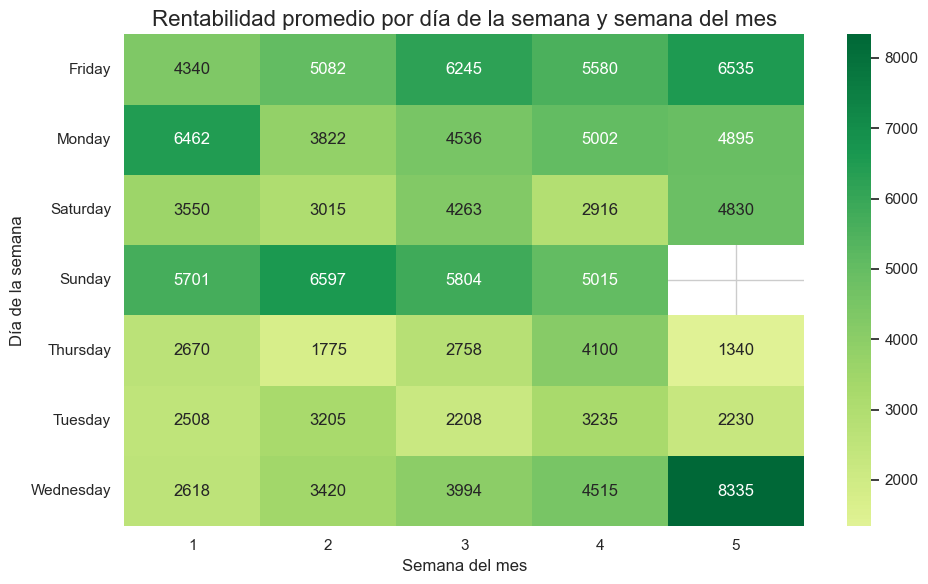

In [30]:
# Heatmap por día de la semana y semana del mes
# Crear columnas auxiliares
ventas_gastos["dia_semana"] = ventas_gastos["Fecha"].dt.day_name()
ventas_gastos["semana_mes"] = ventas_gastos["Fecha"].dt.isocalendar().week - ventas_gastos["Fecha"].dt.month*4 + 4
# Nota: este cálculo de semana_mes depende de cómo quieras numerar semanas dentro del mes.
# Alternativamente puedes usar ventas_gastos["Semana"] directamente.
# Pivotear datos para heatmap
heatmap_data = ventas_gastos.pivot_table(
    index="dia_semana",
    columns="Semana",
    values="rentabilidad_diaria",
    aggfunc="mean"
)
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Rentabilidad promedio por día de la semana y semana del mes", fontsize=16)
plt.xlabel("Semana del mes")
plt.ylabel("Día de la semana")
plt.tight_layout()
plt.show()

In [31]:
#Resumen estadístico por día de la semana
# Crear columna de día de la semana
ventas_gastos["dia_semana"] = ventas_gastos["Fecha"].dt.day_name()
# Calcular estadísticas descriptivas
resumen_dias = ventas_gastos.groupby("dia_semana")["rentabilidad_diaria"].agg(
    ["count","mean","median","min","max"]
).reset_index()
# Ordenar por día de la semana (lunes a domingo)
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
resumen_dias["dia_semana"] = pd.Categorical(resumen_dias["dia_semana"], categories=orden_dias, ordered=True)
resumen_dias = resumen_dias.sort_values("dia_semana")
print(resumen_dias)

  dia_semana  count         mean  median     min     max
1     Monday      9  4949.000000  4655.0  3370.0  9553.0
5    Tuesday     10  2705.000000  2752.5  1440.0  3885.0
6  Wednesday     10  4004.900000  3595.0  2250.0  8335.0
4   Thursday      7  2453.714286  2351.0  1340.0  4100.0
0     Friday      9  5447.777778  4975.0  3925.0  7515.0
2   Saturday      9  3590.888889  4190.0  1642.5  4830.0
3     Sunday      9  5770.555556  5465.0  4270.0  7369.0


C:\Users\EndUser\AppData\Local\Temp\ipykernel_7492\4214566962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


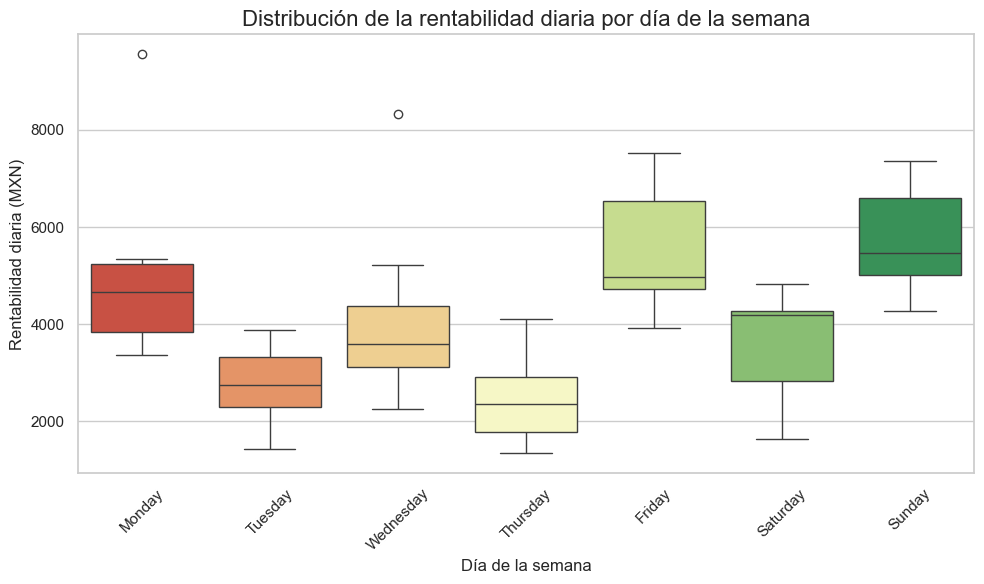

In [32]:
# Ordenar días de la semana
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
ventas_gastos["dia_semana"] = pd.Categorical(
    ventas_gastos["Fecha"].dt.day_name(),
    categories=orden_dias,
    ordered=True
)
#Boxplot de rentabilidad por día de la semana
plt.figure(figsize=(10,6))
sns.boxplot(
    data=ventas_gastos,
    x="dia_semana",
    y="rentabilidad_diaria",
    palette="RdYlGn"
)
# Títulos y etiquetas
plt.title("Distribución de la rentabilidad diaria por día de la semana", fontsize=16)
plt.xlabel("Día de la semana")
plt.ylabel("Rentabilidad diaria (MXN)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretación
- Días fuertes: Viernes y domingo son estratégicos para promociones o eventos, porque ya de por sí generan más rentabilidad.
- Días débiles: Martes y jueves podrían necesitar estrategias de impulso (descuentos, campañas, experiencias especiales).
- Oportunidades ocultas: Aunque lunes y miércoles no tienen la mediana más alta, sus outliers muestran que pueden convertirse en días muy rentables bajo ciertas condiciones.


# Conclusión
- Promociones: conviene reforzar los días flojos (lunes, martes, jueves).
- Estrategia: aprovechar los días buenos (viernes, sábado, domingo) para introducir nuevos productos o campañas.
- Insight clave: la rentabilidad es un mejor indicador que las ventas para tomar decisiones estratégicas.


# Enfoque de machine learning para poder predecir cuales días merecen promoción

# Objetivo
- Predecir qué días son candidatos para aplicar una promoción.
- Basado en patrones de ventas, rentabilidad diaria, y día de la semana.

# Variables a usar
- Fecha → para extraer día de la semana, mes, festivos.
- Total por día → ventas brutas.
- Rentabilidad diaria → ventas – gasto proporcional.
- Categoría del día → flojo, normal, bueno (clasificación previa).


# Modelo sugerido
- Clasificación supervisada:
- Algoritmos como Random Forest, Gradient Boosting (XGBoost, LightGBM, CatBoost).
- Estos modelos manejan bien variables categóricas y numéricas.
- Target (variable objetivo):
- promocion = 1 si el día es flojo (rentabilidad baja).
- promocion = 0 si el día es normal o bueno.

## Flujo de trabajo

1) Preparar dataset:
- Crear columna promocion (1 si flojo, 0 si no).
- Features: día de la semana, ventas, rentabilidad, semana del mes.
  
2) Entrenar modelo:
- Dividir en train/test.
- Entrenar RandomForest o XGBoost.

3) Evaluar modelo:
- Métricas: accuracy, F1-score, matriz de confusión.
  
4) Aplicar predicciones:
- El modelo marcará qué días futuros son candidatos para promoción.

## Creación de la columna de Promoción para tenerla como objetivo donde se añadira un 0 si es un día bueno y 1 si se debería aplicar una promoción

In [33]:
ventas_gastos["promoción"] = ventas_gastos["categoria_dia"].apply(lambda x: 1 if x=="flojo" else 0)

In [34]:
#Caracteristicas y objetivo
Features = ventas_gastos[["Total por dia","rentabilidad_diaria","Semana","dia_semana"]]
Features = pd.get_dummies(Features,columns=["dia_semana"],drop_first=True)
Target = ventas_gastos["promoción"]

In [35]:
#División del Dataset en entrenamiento y test
Features_train, Features_test, Target_train, Target_test = train_test_split(Features,Target,test_size=0.25,random_state=42)

In [36]:
# Entrenar modelo Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(Features_train, Target_train)

RandomForestClassifier(random_state=42)

In [38]:
#Evaluación
Target_pred = model.predict(Features_test)
print(classification_report(Target_test, Target_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



Conclusiones del modelo: 
- Fortalezas: clasificó perfectamente los días flojos y no flojos en tu dataset de prueba, mostrando alta precisión y facilidad para interpretar la importancia de las variables.
- Riesgo: el resultado perfecto puede ser señal de sobreajuste; conviene validar con más datos y usar técnicas como validación cruzada.
- Insight clave: el modelo detecta que la rentabilidad diaria y el día de la semana son los factores más influyentes, más que las ventas brutas.
- Aplicación práctica: sirve como herramienta inicial para decidir cuándo lanzar promociones, especialmente en días flojos, pero debe complementarse con más datos para asegurar que generalice bien.